# Load DIV30 and DIV90 Raw 10x Samples to AnnData

This notebook defines a small in-notebook builder class for raw 10x sample loading. The immediate focus is DIV30, but the same object works for DIV90 or both time points by changing `target_divs`.

The builder reads per-sample 10x matrices from `metadata/div30_div90_sample_id_to_biolabel_map.tsv`, adds sample metadata to `.obs`, makes cell IDs unique by prefixing the 10x barcode with `run_sample_id`, and can return either a standard combined `AnnData` or, if `snapatac2` is available, a backed `AnnDataSet`.


In [17]:
from dataclasses import dataclass
from pathlib import Path
from typing import Optional, Sequence, Tuple

import anndata as ad
import matplotlib.pyplot as plt
import pandas as pd
import scanpy as sc


In [18]:
@dataclass
class Raw10xAnnDataBuilder:
    """Notebook-local builder for raw DIV30/DIV90 10x AnnData objects."""

    project_root: Path
    target_divs: Sequence[str] = ("DIV30",)
    target_run_sample_ids: Optional[Sequence[str]] = None
    sample_map_name: str = "metadata/div30_div90_sample_id_to_biolabel_map.tsv"
    strict_missing_matrix_dirs: bool = True

    @property
    def sample_map_tsv(self) -> Path:
        return self.project_root / self.sample_map_name

    def sample_table(self) -> pd.DataFrame:
        """Return filtered sample metadata with the per-sample 10x matrix path."""
        sample_map = pd.read_csv(self.sample_map_tsv, sep="\t")
        required = {"DIV", "run_sample_id", "biological_label", "per_sample_metrics_csv"}
        missing = required.difference(sample_map.columns)
        if missing:
            raise ValueError(f"Sample map is missing required columns: {sorted(missing)}")

        sample_map = sample_map[sample_map["DIV"].isin(self.target_divs)].copy()
        if self.target_run_sample_ids is not None:
            sample_map = sample_map[sample_map["run_sample_id"].isin(self.target_run_sample_ids)].copy()
            found = set(sample_map["run_sample_id"].astype(str))
            missing_ids = [sid for sid in self.target_run_sample_ids if sid not in found]
            if missing_ids:
                raise ValueError(f"Missing requested run_sample_id values in sample map: {missing_ids}")

        if sample_map.empty:
            raise ValueError("No samples matched target_divs/target_run_sample_ids.")

        sample_map["DIV"] = pd.Categorical(sample_map["DIV"], categories=self.target_divs, ordered=True)
        if self.target_run_sample_ids is not None:
            sample_map["run_sample_id"] = pd.Categorical(
                sample_map["run_sample_id"],
                categories=self.target_run_sample_ids,
                ordered=True,
            )
        sample_map = sample_map.sort_values(["DIV", "run_sample_id"]).reset_index(drop=True)
        sample_map["matrix_dir"] = sample_map["per_sample_metrics_csv"].map(
            lambda p: str(Path(p).parent / "count" / "sample_filtered_feature_bc_matrix")
        )
        return sample_map

    def read_one_sample(self, row: pd.Series) -> ad.AnnData:
        """Read one per-sample 10x matrix and annotate cells with sample metadata."""
        matrix_dir = Path(row["matrix_dir"])
        if not matrix_dir.exists():
            raise FileNotFoundError(f"Missing per-sample 10x matrix directory: {matrix_dir}")

        one = sc.read_10x_mtx(matrix_dir, var_names="gene_symbols", make_unique=True)
        run_sample_id = str(row["run_sample_id"])

        # 10x barcodes can repeat across samples, so make obs_names unique before combining.
        one.obs_names = [f"{run_sample_id}:{barcode}" for barcode in one.obs_names]
        one.obs["DIV"] = str(row["DIV"])
        one.obs["run_sample_id"] = run_sample_id
        one.obs["biological_label"] = str(row["biological_label"])
        one.obs["matrix_dir"] = str(matrix_dir)
        return one

    def component_anndatas(self):
        """Return `(run_sample_id, AnnData)` pairs for selected samples."""
        components = []
        missing_dirs = []

        for _, row in self.sample_table().iterrows():
            matrix_dir = Path(row["matrix_dir"])
            if not matrix_dir.exists():
                missing_dirs.append(str(matrix_dir))
                continue
            components.append((str(row["run_sample_id"]), self.read_one_sample(row)))

        if missing_dirs:
            message = "Missing per-sample 10x matrix directories:\n" + "\n".join(f" - {p}" for p in missing_dirs)
            if self.strict_missing_matrix_dirs:
                raise FileNotFoundError(message)
            print(message)

        if not components:
            raise FileNotFoundError("No per-sample 10x matrix directories were found.")

        return components

    def combined_anndata(self) -> ad.AnnData:
        """Build one standard AnnData by stacking cells from selected samples."""
        sample_map = self.sample_table()
        combined = ad.concat(
            [one for _, one in self.component_anndatas()],
            axis=0,
            join="outer",
            merge="same",
            fill_value=0,
            index_unique=None,
        )
        self._finalize_obs(combined, sample_map)
        combined.uns["sample_map_tsv"] = str(self.sample_map_tsv)
        combined.uns["target_divs"] = list(self.target_divs)
        combined.uns["combine_logic"] = (
            "Per-sample 10x matrices were read separately, annotated, barcode-prefixed by "
            "run_sample_id, and concatenated along observations with an outer gene join."
        )
        return combined

    def anndata_set(self, filename: Path, add_key: str = "run_sample_id"):
        """Build a backed snapatac2 AnnDataSet from selected per-sample AnnData objects."""
        try:
            import snapatac2 as snap
        except ModuleNotFoundError as exc:
            raise ModuleNotFoundError("Install snapatac2 to use AnnDataSet output.") from exc

        filename = Path(filename)
        filename.parent.mkdir(parents=True, exist_ok=True)
        return snap.AnnDataSet(
            adatas=self.component_anndatas(),
            filename=str(filename),
            add_key=add_key,
        )

    def cell_count_tables(self, adata: ad.AnnData) -> Tuple[pd.DataFrame, pd.DataFrame]:
        """Return per-sample and per-DIV cell count summaries."""
        sample_counts = (
            adata.obs.groupby(["DIV", "run_sample_id", "biological_label"], observed=True)
            .size()
            .rename("n_cells")
            .reset_index()
            .sort_values(["DIV", "run_sample_id"])
            .reset_index(drop=True)
        )
        div_counts = adata.obs.groupby("DIV", observed=True).size().rename("n_cells").reset_index()
        return sample_counts, div_counts

    def _finalize_obs(self, adata: ad.AnnData, sample_map: pd.DataFrame) -> None:
        if not adata.obs_names.is_unique:
            duplicated = adata.obs_names[adata.obs_names.duplicated()].unique()[:10].tolist()
            raise ValueError(f"Combined AnnData has duplicated obs_names. Examples: {duplicated}")

        adata.obs["DIV"] = pd.Categorical(adata.obs["DIV"], categories=self.target_divs, ordered=True)
        adata.obs["run_sample_id"] = pd.Categorical(
            adata.obs["run_sample_id"],
            categories=sample_map["run_sample_id"].astype(str).tolist(),
            ordered=True,
        )
        adata.obs["biological_label"] = adata.obs["biological_label"].astype("string")
        adata.obs["matrix_dir"] = adata.obs["matrix_dir"].astype("string")


In [19]:
def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "metadata" / "div30_div90_sample_id_to_biolabel_map.tsv").exists():
            return candidate
    raise FileNotFoundError("Could not find project root containing metadata/div30_div90_sample_id_to_biolabel_map.tsv")


PROJECT_ROOT = find_project_root(Path.cwd().resolve())

builder = Raw10xAnnDataBuilder(
    project_root=PROJECT_ROOT,
    target_divs=("DIV30",),
    target_run_sample_ids=(
        "9853-MW-1",
        "9853-MW-2",
        "9853-MW-3",
        "9853-MW-4",
        "9853-MW-5",
        "9853-MW-6",
    ),
)

sample_map = builder.sample_table()
print(f"Selected {len(sample_map)} samples from: {builder.sample_map_tsv}")
display(sample_map[["DIV", "run_sample_id", "biological_label", "matrix_dir"]])

Selected 6 samples from: /home/elcrespo/Desktop/githubprojects/mge_organoid_pipeline/metadata/div30_div90_sample_id_to_biolabel_map.tsv


,DIV,run_sample_id,biological_label,matrix_dir
0,DIV30,9853-MW-1,H9_rep1,/nfs/turbo/umms-parent/Manny_test/9583-MW-rean...
1,DIV30,9853-MW-2,H9_rep2,/nfs/turbo/umms-parent/Manny_test/9583-MW-rean...
2,DIV30,9853-MW-3,79B_rep1,/nfs/turbo/umms-parent/Manny_test/9583-MW-rean...
3,DIV30,9853-MW-4,79B_rep2,/nfs/turbo/umms-parent/Manny_test/9583-MW-rean...
4,DIV30,9853-MW-5,2E_rep1,/nfs/turbo/umms-parent/Manny_test/9583-MW-rean...
5,DIV30,9853-MW-6,2E_rep2,/nfs/turbo/umms-parent/Manny_test/9583-MW-rean...


In [20]:
# Build the standard combined AnnData object for downstream Scanpy work.
sample_adata = builder.combined_anndata()

print("Combined AnnData shape:", sample_adata.shape)
print("Loaded run_sample_id count:", sample_adata.obs["run_sample_id"].nunique())
print("Unique cell IDs:", sample_adata.obs_names.is_unique)


Combined AnnData shape: (107020, 18082)
Loaded run_sample_id count: 6
Unique cell IDs: True


In [21]:
# Multisample sanity checks: per-sample and per-DIV cell totals.
sample_cell_counts, div_cell_counts = builder.cell_count_tables(sample_adata)

print("obs columns:", list(sample_adata.obs.columns))
print("Samples loaded:", sample_cell_counts["run_sample_id"].nunique())
display(sample_cell_counts)
display(div_cell_counts)


obs columns: ['DIV', 'run_sample_id', 'biological_label', 'matrix_dir']
Samples loaded: 6


,DIV,run_sample_id,biological_label,n_cells
0,DIV30,9853-MW-1,H9_rep1,18047
1,DIV30,9853-MW-2,H9_rep2,6060
2,DIV30,9853-MW-3,79B_rep1,17928
3,DIV30,9853-MW-4,79B_rep2,13047
4,DIV30,9853-MW-5,2E_rep1,26408
5,DIV30,9853-MW-6,2E_rep2,25530


,DIV,n_cells
0,DIV30,107020


In [22]:
# Quick object preview
sample_adata


AnnData object with n_obs × n_vars = 107020 × 18082
    obs: 'DIV', 'run_sample_id', 'biological_label', 'matrix_dir'
    var: 'gene_ids', 'feature_types'
    uns: 'sample_map_tsv', 'target_divs', 'combine_logic'

## First-Pass QC Metrics

This section computes standard Scanpy QC metrics on the combined DIV30 object and then summarizes them by `run_sample_id`. At this stage, `run_sample_id` is the batch/sample key, so per-sample QC is the right first view before filtering cells.


In [23]:
# Compute per-cell QC metrics once on the combined object.
# These columns are added to sample_adata.obs and can be summarized by sample afterward.
QC_GROUP_KEY = "run_sample_id"
QC_METRICS = ["total_counts", "n_genes_by_counts", "pct_counts_mt"]

# Mark mitochondrial genes. Human gene symbols usually use MT- prefixes.
sample_adata.var["mt"] = sample_adata.var_names.str.upper().str.startswith("MT-")

sc.pp.calculate_qc_metrics(
    sample_adata,
    qc_vars=["mt"],
    percent_top=[20, 50, 100],
    log1p=True,
    inplace=True,
)

print("Added QC columns to sample_adata.obs:")
display(sample_adata.obs[[QC_GROUP_KEY, "biological_label", *QC_METRICS]].head())


Added QC columns to sample_adata.obs:


,run_sample_id,biological_label,total_counts,n_genes_by_counts,pct_counts_mt
9853-MW-1:AAACAAGCAAGATAAGACTTTAGG-1,9853-MW-1,H9_rep1,8408.0,4355,0.047574
9853-MW-1:AAACAAGCAAGCCTAAACTTTAGG-1,9853-MW-1,H9_rep1,2046.0,1440,0.830890
9853-MW-1:AAACAAGCAAGGCCATACTTTAGG-1,9853-MW-1,H9_rep1,4643.0,2659,0.990739
9853-MW-1:AAACAAGCAATATGGTACTTTAGG-1,9853-MW-1,H9_rep1,6359.0,3742,1.320962
9853-MW-1:AAACAAGCACTAACGAACTTTAGG-1,9853-MW-1,H9_rep1,6076.0,3565,0.773535


In [24]:
# Per-sample QC summary table.
# This is the first check for whether one run sample has unusually low counts,
# few detected genes, or high mitochondrial percentage compared with the others.
per_sample_qc = (
    sample_adata.obs.groupby(["run_sample_id", "biological_label"], observed=True)
    .agg(
        n_cells=("run_sample_id", "size"),
        median_total_counts=("total_counts", "median"),
        mean_total_counts=("total_counts", "mean"),
        median_n_genes_by_counts=("n_genes_by_counts", "median"),
        mean_n_genes_by_counts=("n_genes_by_counts", "mean"),
        median_pct_counts_mt=("pct_counts_mt", "median"),
        mean_pct_counts_mt=("pct_counts_mt", "mean"),
        pct_cells_mt_gt_10=("pct_counts_mt", lambda x: 100 * (x > 10).mean()),
        pct_cells_mt_gt_20=("pct_counts_mt", lambda x: 100 * (x > 20).mean()),
    )
    .reset_index()
)

# Round for display only; the original per-cell QC values remain in sample_adata.obs.
per_sample_qc_display = per_sample_qc.copy()
float_cols = per_sample_qc_display.select_dtypes(include="number").columns.difference(["n_cells"])
per_sample_qc_display[float_cols] = per_sample_qc_display[float_cols].round(2)

display(per_sample_qc_display)


,run_sample_id,biological_label,n_cells,median_total_counts,mean_total_counts,median_n_genes_by_counts,mean_n_genes_by_counts,median_pct_counts_mt,mean_pct_counts_mt,pct_cells_mt_gt_10,pct_cells_mt_gt_20
0,9853-MW-1,H9_rep1,18047,6673.0,8011.299805,3692.0,3807.85,0.27,0.52,0.01,0.01
1,9853-MW-2,H9_rep2,6060,6901.0,8155.910156,3809.0,3668.65,0.25,0.74,0.10,0.03
2,9853-MW-3,79B_rep1,17928,8330.0,9524.540039,4137.0,4171.58,0.34,0.46,0.00,0.00
3,9853-MW-4,79B_rep2,13047,6433.0,7263.970215,3626.0,3596.58,0.17,0.52,0.11,0.00
4,9853-MW-5,2E_rep1,26408,7465.0,8809.959961,4049.0,4142.33,0.20,0.38,0.00,0.00
5,9853-MW-6,2E_rep2,25530,8601.5,10899.150391,4377.0,4599.62,0.16,0.29,0.01,0.00


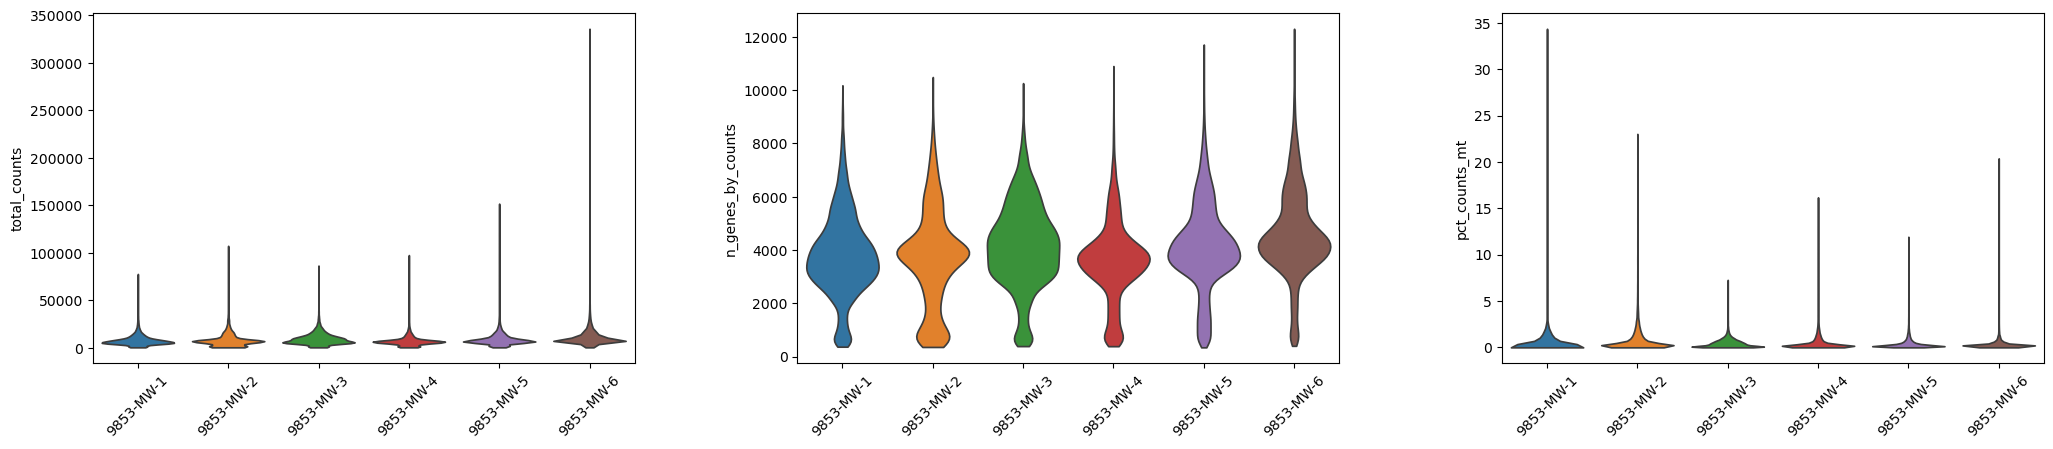

In [25]:
# Violin plots grouped by sample.
# These show the per-cell distributions for each run sample side by side.
sc.pl.violin(
    sample_adata,
    QC_METRICS,
    groupby=QC_GROUP_KEY,
    rotation=45,
    stripplot=False,
    multi_panel=True,
)


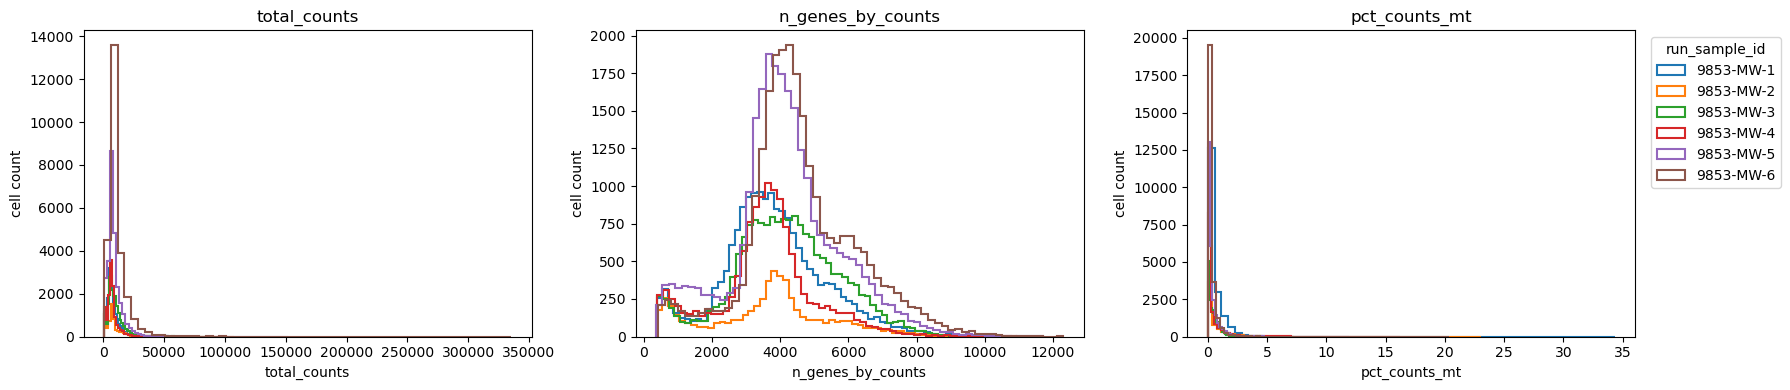

In [26]:
# Histogram overlays by sample for the same QC metrics.
# This view can make sample-level shifts easier to see than violins.
qc_plot_df = sample_adata.obs[[QC_GROUP_KEY, *QC_METRICS]].copy()

fig, axes = plt.subplots(1, len(QC_METRICS), figsize=(18, 4))
for ax, metric in zip(axes, QC_METRICS):
    for run_sample_id, group in qc_plot_df.groupby(QC_GROUP_KEY, observed=True):
        ax.hist(group[metric].dropna(), bins=60, histtype="step", linewidth=1.5, label=str(run_sample_id))
    ax.set_title(metric)
    ax.set_xlabel(metric)
    ax.set_ylabel("cell count")

axes[-1].legend(title=QC_GROUP_KEY, bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()


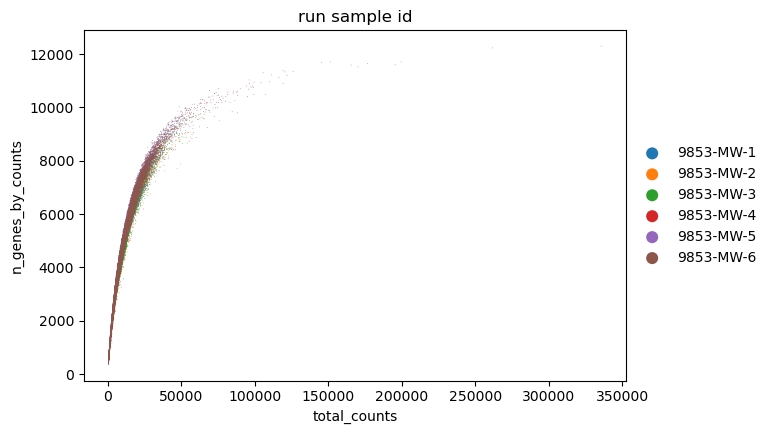

In [27]:
# Optional scatter view: counts vs detected genes, colored by sample.
# This is useful for spotting sample-specific clouds or outliers.
sc.pl.scatter(
    sample_adata,
    x="total_counts",
    y="n_genes_by_counts",
    color=QC_GROUP_KEY,
)


In [28]:
sample_adata.obs["run_sample_id"].value_counts()

run_sample_id
9853-MW-5    26408
9853-MW-6    25530
9853-MW-1    18047
9853-MW-3    17928
9853-MW-4    13047
9853-MW-2     6060
Name: count, dtype: int64

In [29]:
# Minimal metadata previews used in QC reporting
display(sample_adata.obs[["DIV", "run_sample_id", "biological_label"]].head())
display(sample_adata.var.head())


,DIV,run_sample_id,biological_label
9853-MW-1:AAACAAGCAAGATAAGACTTTAGG-1,DIV30,9853-MW-1,H9_rep1
9853-MW-1:AAACAAGCAAGCCTAAACTTTAGG-1,DIV30,9853-MW-1,H9_rep1
9853-MW-1:AAACAAGCAAGGCCATACTTTAGG-1,DIV30,9853-MW-1,H9_rep1
9853-MW-1:AAACAAGCAATATGGTACTTTAGG-1,DIV30,9853-MW-1,H9_rep1
9853-MW-1:AAACAAGCACTAACGAACTTTAGG-1,DIV30,9853-MW-1,H9_rep1


,gene_ids,feature_types,mt,n_cells_by_counts,mean_counts,log1p_mean_counts,pct_dropout_by_counts,total_counts,log1p_total_counts
SAMD11,ENSG00000187634,Gene Expression,False,2954,0.034816,0.034224,97.239768,3726.0,8.223359
NOC2L,ENSG00000188976,Gene Expression,False,37217,0.494216,0.401602,65.224257,52891.0,10.876007
KLHL17,ENSG00000187961,Gene Expression,False,24539,0.296150,0.259399,77.070641,31694.0,10.363914
PLEKHN1,ENSG00000187583,Gene Expression,False,919,0.009456,0.009412,99.141282,1012.0,6.920671
PERM1,ENSG00000187642,Gene Expression,False,742,0.008811,0.008773,99.306672,943.0,6.850126
